# Invest & Expand — Deep Optimization Analysis

**Budget**: 50,000 XIRECs  
**Goal**: Maximize `PnL = Research(r) × Scale(s) × Speed(m) − Budget_Used`

Allocations are percentages 0–100 of budget, summing to ≤100%.

---
**Notebook sections:**
1. Model definition & helper functions
2. Analytical optimality conditions (closed-form FOC)
3. PnL surface visualization
4. Sensitivity analysis
5. Optimal PnL across speed multipliers
6. Competitive speed analysis (Nash equilibrium)
7. Strategic heatmap: overbid vs underbid speed
8. Rank-jump analysis given opponent beliefs
9. Final recommendation engine

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import brentq
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
fmt = mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')

## 1. Model Definition

In [28]:
# ═══════════════════════════════════════════
# GLOBAL PARAMETERS — tune freely
# ═══════════════════════════════════════════
BUDGET       = 50_000
RESEARCH_MAX = 200_000
SCALE_MAX    = 7
SCALE_INT = True
SPEED_TOP    = 0.9
SPEED_BOT    = 0.1
SPEED_DECIMAL = 1
N_PLAYERS    = 10_000      # Total players in your game
# ═══════════════════════════════════════════

def research(x):
    x = np.asarray(x, dtype=float)
    return RESEARCH_MAX * np.log(1 + x) / np.log(1 + 100)

def scale(x):
    result = SCALE_MAX * np.asarray(x, dtype=float) / 100
    if SCALE_INT:
        return np.floor(result).astype(int)
    return result

def pnl(r, s, p, m):
    gross = research(r) * scale(s) * m
    cost  = (np.asarray(r) + np.asarray(s) + np.asarray(p)) / 100 * BUDGET
    return gross - cost

def compute_speed_multipliers(speed_allocs):
    """Rank-based speed multipliers. Ties share the MINIMUM (best) rank of their group."""
    allocs = np.array(speed_allocs, dtype=float)
    n = len(allocs)
    
    if n == 1:
        raw_multipliers = np.array([SPEED_TOP])
    else:
        sorted_unique = np.sort(np.unique(allocs))[::-1]
        rank_map = {}
        pos = 1
        
        for val in sorted_unique:
            cnt = np.sum(allocs == val)
            rank_map[val] = pos   # minimum rank for tie group
            pos += cnt
            
        ranks = np.array([rank_map[a] for a in allocs])
        raw_multipliers = SPEED_TOP + (SPEED_BOT - SPEED_TOP) * (ranks - 1) / (n - 1)
    
    if SPEED_DECIMAL is not None:
        factor = 10 ** SPEED_DECIMAL
        result = np.floor(raw_multipliers * factor) / factor
        
        if SPEED_DECIMAL == 0:
            return result.astype(int)
            
        return result
        
    return raw_multipliers

# # Verify examples from the problem statement
# t1 = compute_speed_multipliers([95, 20, 10])
# assert np.allclose(t1, [0.9, 0.5, 0.1]), f'Test1 failed: {t1}'
# t2 = compute_speed_multipliers([70,70,70,50,40,40,30])
# # Ranks 1,1,1,4,5,5,7 -> mults 0.9,0.9,0.9,0.5,~0.37,~0.37,0.1
# assert np.allclose(t2[:3], 0.9) and abs(t2[-1]-0.1)<1e-9 and abs(t2[3]-0.5)<1e-9
# t1 = compute_speed_multipliers([95, 20, 10])
# assert np.allclose(t1, [0.9, 0.5, 0.1]), f'Failed: {t1}'
# t2 = compute_speed_multipliers([70,70,70,50,40,40,30])
# assert abs(t2[0]-0.9) < 1e-9 and abs(t2[-1]-0.1) < 1e-9
# print('All model checks passed.')
# print(f'  research(0)={research(0):.0f}, research(100)={research(100):.0f}')
# print(f'  scale(0)={scale(0):.2f}, scale(100)={scale(100):.2f}')

## 2. Analytical Optimality Conditions

### Derivation

Maximize `PnL = R(r) · S(s) · m − (r+s+p)/100 · B`

**Key structural observation**: `p` (Speed) only appears in the cost term, not the gross. It enters only through the competitive rank mechanism — handled separately.

For fixed `p` and speed multiplier `m`, with `r+s = T`:

$$\frac{\partial\text{PnL}}{\partial r} = R'(r)\cdot S(s)\cdot m - \frac{B}{100} = 0$$
$$\frac{\partial\text{PnL}}{\partial s} = R(r)\cdot S'(s)\cdot m - \frac{B}{100} = 0$$

Dividing: $\dfrac{R'(r)}{R(r)} = \dfrac{S'(s)}{S(s)}$

Substituting $R(r) = C\cdot\ln(1+r)/\ln(101)$ and $S(s) = D\cdot s$:

$$\frac{1}{(1+r)\ln(1+r)} = \frac{1}{s} \implies \boxed{s = (1+r)\ln(1+r)}$$

Combined with $r+s=T$: solve $r + (1+r)\ln(1+r) = T$ numerically.

**This R/S split is independent of `m` and `p`** — the ratio is a universal constant for any fixed T.

In [31]:
def optimal_rs_given_total(T, m=0.5):
    """Analytical FOC: given total T=r+s%, return (r, s, pnl_with_p0)."""
    if T <= 1e-9:
        return 0.0, 0.0, 0.0
    def foc(r):
        return r + (1+r)*np.log(1+r) - T
    if foc(0) >= 0:
        r, s = T, 0.0
    else:
        r = brentq(foc, 0, T, xtol=1e-12)
        s = T - r
    return r, s, pnl(r, s, 0, m)

def best_allocation(m, p_pct=0.0, n_scan=2000):
    """Find best (r, s) and optimal T for given speed multiplier and p."""
    max_T = 100 - p_pct
    T_vals = np.linspace(0, max_T, n_scan)
    best_v, best_T = -np.inf, 0.0
    for T in T_vals:
        r, s, _ = optimal_rs_given_total(T, m)
        v = pnl(r, s, p_pct, m)
        if v > best_v:
            best_v, best_T = v, T
    r, s, _ = optimal_rs_given_total(best_T, m)
    return r, s, pnl(r, s, p_pct, m)

print('Optimal allocations by speed multiplier (p=0):')
print(f"{'R%':>8} {'S%':>8} | {'Research':>10} {'Scale':>8} {'Speed':>8} | {'Total%':>8} {'Gross':>14} {'Net PnL':>14}")
print('-'*89)
for m in [0.1, 0.3, 0.5, 0.7, 0.9]:
    r, s, v = best_allocation(m)
    g = research(r)*scale(s)*m
    print(f"{r:>8.2f} {s:>8.2f} | {research(s):>10.1f} {scale(s):>8.0f} {m:>8.1f} | {r+s:>8.2f} {g:>14,.1f} {v:>14,.1f}")

print('\n→ The R/S split is stable across m values; only net PnL changes.')

Optimal allocations by speed multiplier (p=0):
      R%       S% |   Research    Scale    Speed |   Total%          Gross        Net PnL
-----------------------------------------------------------------------------------------
   21.84    71.46 |   185606.6        5      0.1 |    93.30       67,788.6       21,140.3
   23.14    76.86 |   188723.5        5      0.3 |   100.00      206,964.1      156,964.1
   23.14    76.86 |   188723.5        5      0.5 |   100.00      344,940.2      294,940.2
   23.14    76.86 |   188723.5        5      0.7 |   100.00      482,916.3      432,916.3
   23.14    76.86 |   188723.5        5      0.9 |   100.00      620,892.4      570,892.4

→ The R/S split is stable across m values; only net PnL changes.


## 3. PnL Surface Visualization

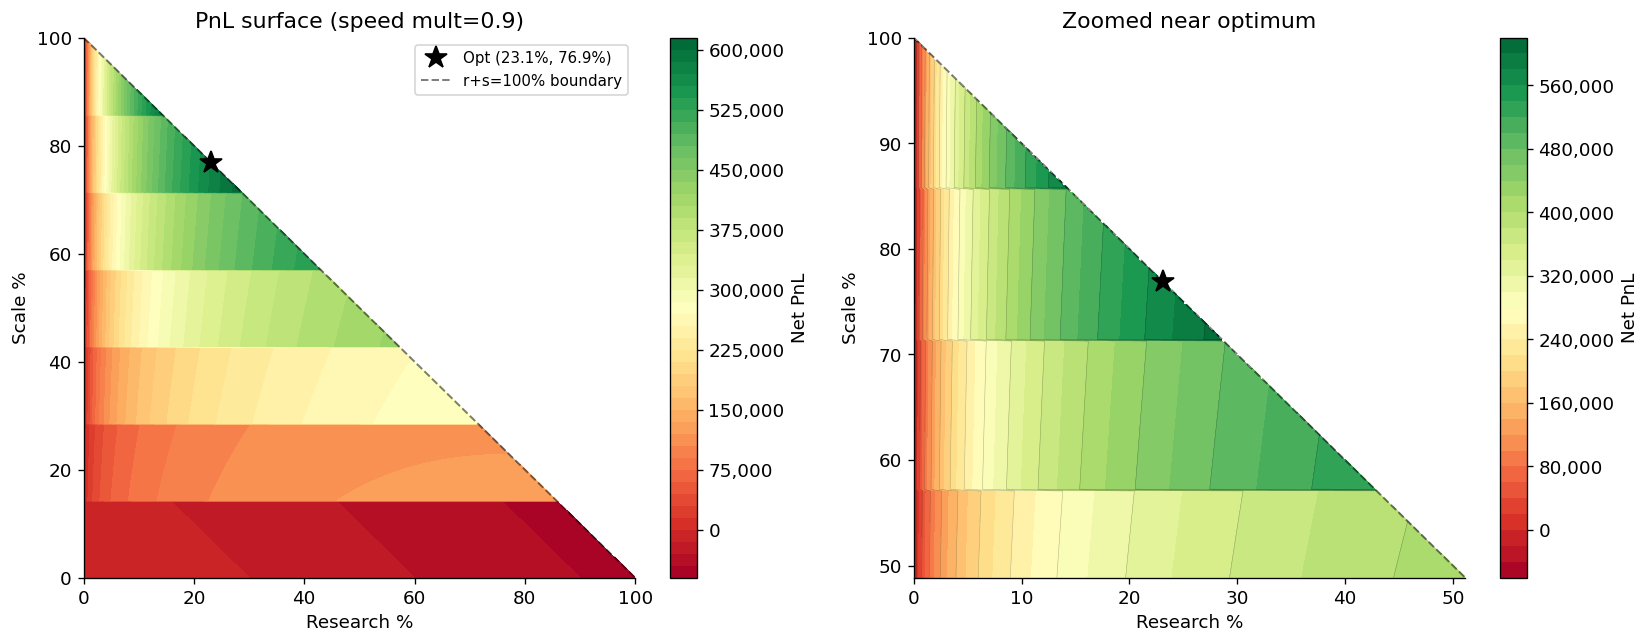

Optimum: R=23.14%, S=76.86%, Net PnL=570,892.36
FOC check: (1+r)ln(1+r)=76.860, s=76.860


In [32]:
# ═══════════════════════════
SURFACE_SPEED_MULT = 0.9
# ═══════════════════════════

r_vals = np.linspace(0, 100, 400)
s_vals = np.linspace(0, 100, 400)
R, S = np.meshgrid(r_vals, s_vals)
PNL = np.where(R+S <= 100, pnl(R, S, 0, SURFACE_SPEED_MULT), np.nan)

r_opt, s_opt, pnl_opt = best_allocation(SURFACE_SPEED_MULT)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
c = ax.contourf(R, S, PNL, levels=60, cmap='RdYlGn')
plt.colorbar(c, ax=ax, label='Net PnL').ax.yaxis.set_major_formatter(fmt)
ax.plot(r_opt, s_opt, 'k*', ms=14, label=f'Opt ({r_opt:.1f}%, {s_opt:.1f}%)')
t = np.linspace(0, 100, 200)
ax.plot(t, 100-t, 'k--', lw=1.2, alpha=0.5, label='r+s=100% boundary')
ax.set(xlabel='Research %', ylabel='Scale %',
       title=f'PnL surface (speed mult={SURFACE_SPEED_MULT})')
ax.legend(fontsize=9)

mg = 28
r2 = np.linspace(max(0,r_opt-mg), min(100,r_opt+mg), 300)
s2 = np.linspace(max(0,s_opt-mg), min(100,s_opt+mg), 300)
R2, S2 = np.meshgrid(r2, s2)
P2 = np.where(R2+S2<=100, pnl(R2,S2,0,SURFACE_SPEED_MULT), np.nan)
ax2 = axes[1]
c2 = ax2.contourf(R2, S2, P2, levels=40, cmap='RdYlGn')
ax2.contour(R2, S2, P2, levels=20, colors='k', linewidths=0.3, alpha=0.3)
plt.colorbar(c2, ax=ax2, label='Net PnL').ax.yaxis.set_major_formatter(fmt)
ax2.plot(r_opt, s_opt, 'k*', ms=14)
ax2.plot(r2, 100-r2, 'k--', lw=1.2, alpha=0.5)
ax2.set(xlabel='Research %', ylabel='Scale %', title='Zoomed near optimum')

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/pnl_surface.png', bbox_inches='tight')
plt.show()
print(f'Optimum: R={r_opt:.2f}%, S={s_opt:.2f}%, Net PnL={pnl_opt:,.2f}')
print(f'FOC check: (1+r)ln(1+r)={(1+r_opt)*np.log(1+r_opt):.3f}, s={s_opt:.3f}')

## 4. Sensitivity Analysis

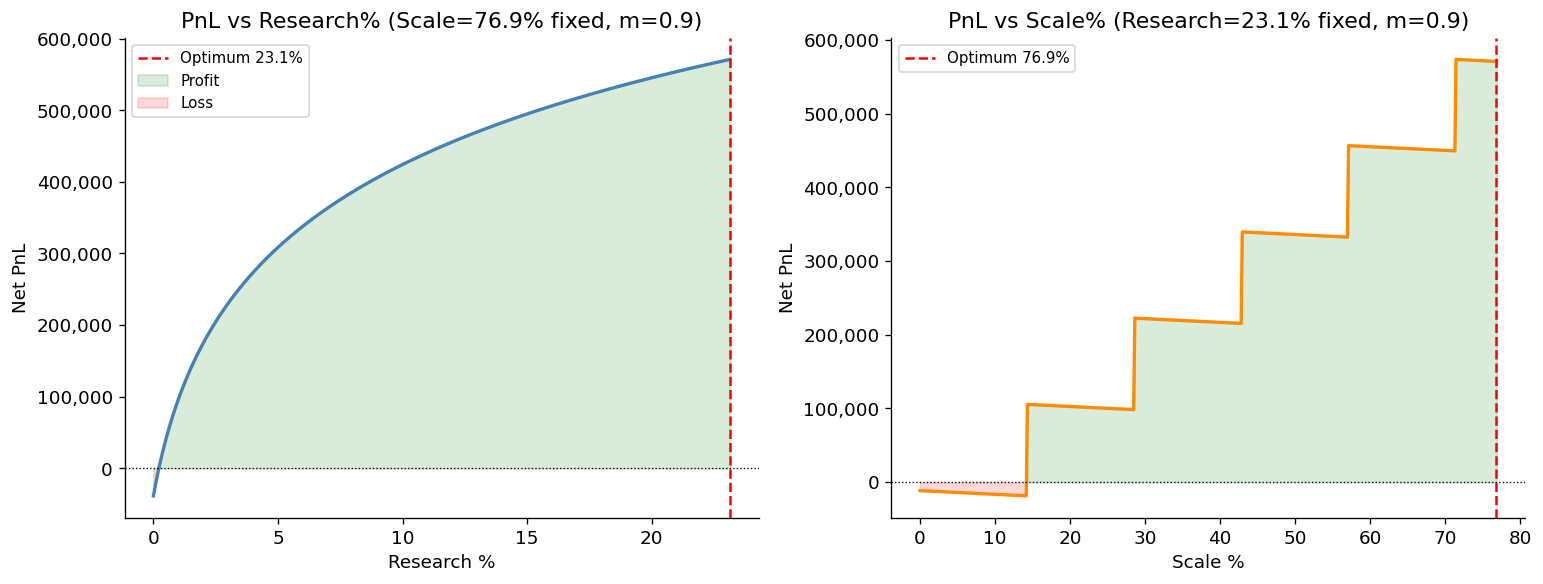

Tolerance table computed considering fixed (m=0.9) - the delta removed from research/scale goes to investment in speed
Baseline: R=23.1%, S=76.9%, PnL=570,892.4  (m=0.9)

  Δ Research%   New%     PnL        Loss
     -20      3.1     237,064.0   -333,828.4
     -10     13.1     471,589.7    -99,302.7
      -5     18.1     528,132.8    -42,759.5
      +5     23.1     570,892.4         +0.0
     +10     23.1     570,892.4         +0.0
     +20     23.1     570,892.4         +0.0

  Δ Scale%   New%     PnL        Loss
     -20     56.9     332,535.4   -238,356.9
     -10     66.9     451,713.9   -119,178.5
      -5     71.9     573,392.4     +2,500.0
      +5     76.9     570,892.4         +0.0
     +10     76.9     570,892.4         +0.0
     +20     76.9     570,892.4         +0.0



In [33]:
r_opt, s_opt, pnl_opt = best_allocation(SURFACE_SPEED_MULT)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Research slice
ax = axes[0]
rng = np.linspace(0, 100-s_opt, 500)
vals = np.array([pnl(x, s_opt, 0, SURFACE_SPEED_MULT) for x in rng])
ax.plot(rng, vals, lw=2, color='steelblue')
ax.axvline(r_opt, color='red', ls='--', lw=1.5, label=f'Optimum {r_opt:.1f}%')
ax.axhline(0, color='k', ls=':', lw=0.8)
ax.fill_between(rng, vals, 0, where=vals>0, alpha=0.15, color='green', label='Profit')
ax.fill_between(rng, vals, 0, where=vals<0, alpha=0.15, color='red', label='Loss')
ax.set(xlabel='Research %', ylabel='Net PnL',
       title=f'PnL vs Research% (Scale={s_opt:.1f}% fixed, m={SURFACE_SPEED_MULT})')
ax.yaxis.set_major_formatter(fmt)
ax.legend(fontsize=9)

# Scale slice
ax2 = axes[1]
rng2 = np.linspace(0, 100-r_opt, 500)
vals2 = np.array([pnl(r_opt, x, 0, SURFACE_SPEED_MULT) for x in rng2])
ax2.plot(rng2, vals2, lw=2, color='darkorange')
ax2.axvline(s_opt, color='red', ls='--', lw=1.5, label=f'Optimum {s_opt:.1f}%')
ax2.axhline(0, color='k', ls=':', lw=0.8)
ax2.fill_between(rng2, vals2, 0, where=vals2>0, alpha=0.15, color='green')
ax2.fill_between(rng2, vals2, 0, where=vals2<0, alpha=0.15, color='red')
ax2.set(xlabel='Scale %', ylabel='Net PnL',
        title=f'PnL vs Scale% (Research={r_opt:.1f}% fixed, m={SURFACE_SPEED_MULT})')
ax2.yaxis.set_major_formatter(fmt)
ax2.legend(fontsize=9)

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/sensitivity.png', bbox_inches='tight')
plt.show()

# Tolerance table
print(f'Tolerance table computed considering fixed (m={SURFACE_SPEED_MULT}) - the delta removed from research/scale goes to investment in speed')
print(f'Baseline: R={r_opt:.1f}%, S={s_opt:.1f}%, PnL={pnl_opt:,.1f}  (m={SURFACE_SPEED_MULT})')
print()
for axis, name, base, limit in [('r','Research',r_opt,100-s_opt), ('s','Scale',s_opt,100-r_opt)]:
    print(f'  Δ {name}%   New%     PnL        Loss')
    for d in [-20,-10,-5,5,10,20]:
        nv = np.clip(base+d, 0, limit)
        v = pnl(nv if axis=='r' else r_opt, s_opt if axis=='r' else nv, 0, SURFACE_SPEED_MULT)
        print(f'    {d:+4d}    {nv:5.1f}  {v:12,.1f}  {v-pnl_opt:+11,.1f}')
    print()

## 5. Optimal PnL Across Speed Multipliers

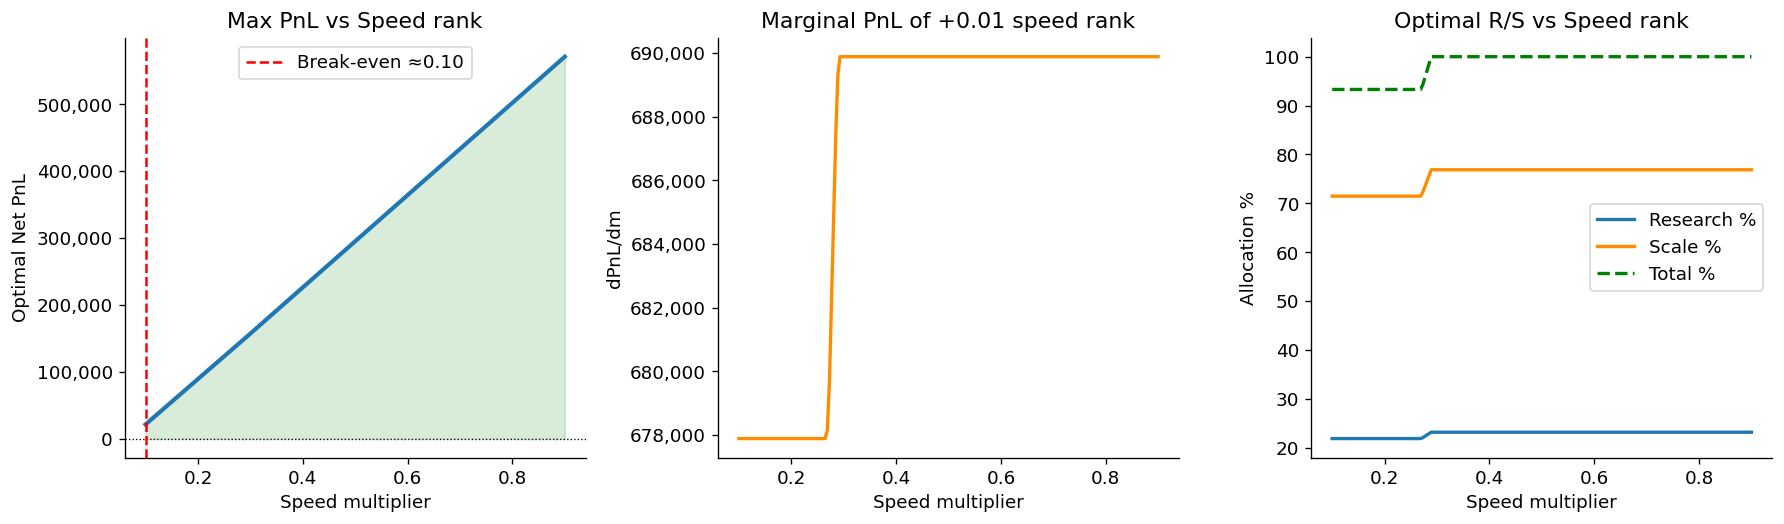

Break-even speed multiplier: 0.100
PnL gain (rank-last → rank-first): +549,752


In [34]:
mult_range = np.linspace(0.1, 0.9, 200)
results = [best_allocation(m) for m in mult_range]
pnl_arr = np.array([v[2] for v in results])
r_arr   = np.array([v[0] for v in results])
s_arr   = np.array([v[1] for v in results])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
ax.plot(mult_range, pnl_arr, lw=2.5)
ax.axhline(0, color='k', ls=':', lw=0.8)
ax.fill_between(mult_range, pnl_arr, 0, where=pnl_arr>0, alpha=0.15, color='green')
ax.fill_between(mult_range, pnl_arr, 0, where=pnl_arr<0, alpha=0.15, color='red')
be_idx = np.argmin(np.abs(pnl_arr))
ax.axvline(mult_range[be_idx], color='red', ls='--', lw=1.5,
           label=f'Break-even ≈{mult_range[be_idx]:.2f}')
ax.set(xlabel='Speed multiplier', ylabel='Optimal Net PnL',
       title='Max PnL vs Speed rank')
ax.yaxis.set_major_formatter(fmt)
ax.legend()

ax2 = axes[1]
dpnl = np.gradient(pnl_arr, mult_range)
ax2.plot(mult_range, dpnl, lw=2, color='darkorange')
ax2.set(xlabel='Speed multiplier', ylabel='dPnL/dm',
        title='Marginal PnL of +0.01 speed rank')
ax2.yaxis.set_major_formatter(fmt)

ax3 = axes[2]
ax3.plot(mult_range, r_arr, lw=2, label='Research %')
ax3.plot(mult_range, s_arr, lw=2, color='darkorange', label='Scale %')
ax3.plot(mult_range, r_arr+s_arr, lw=2, ls='--', color='green', label='Total %')
ax3.set(xlabel='Speed multiplier', ylabel='Allocation %',
        title='Optimal R/S vs Speed rank')
ax3.legend()

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/speed_value.png', bbox_inches='tight')
plt.show()

print(f'Break-even speed multiplier: {mult_range[be_idx]:.3f}')
print(f'PnL gain (rank-last → rank-first): {pnl_arr[-1]-pnl_arr[0]:+,.0f}')

## 6. Competitive Speed Analysis — Nash Equilibrium

In [35]:
def pnl_for_p(my_p, opp_speeds, n_T=300):
    """Compute optimal PnL for a given speed allocation p against opponents."""
    my_m = compute_speed_multipliers(list(opp_speeds) + [my_p])[-1]
    max_T = 100 - my_p
    best_v = -np.inf
    for T in np.linspace(0, max_T, n_T):
        r, s, _ = optimal_rs_given_total(T, my_m)
        v = pnl(r, s, my_p, my_m)
        if v > best_v:
            best_v = v
    return best_v

def best_response_p(opp_speeds, n_p=200):
    p_vals = np.linspace(0, 100, n_p)
    pnl_vals = np.array([pnl_for_p(p, opp_speeds) for p in p_vals])
    bi = np.argmax(pnl_vals)
    return p_vals[bi], pnl_vals[bi], p_vals, pnl_vals

def symmetric_nash(n_players, tol=0.3, max_iter=60):
    p = 12.0
    hist = [p]
    for _ in range(max_iter):
        opp = [p] * (n_players - 1)
        br, _, _, _ = best_response_p(opp, n_p=120)
        p_new = 0.55*br + 0.45*p
        hist.append(p_new)
        if abs(p_new - p) < tol:
            p = p_new
            break
        p = p_new
    return p, hist

print('Symmetric Nash equilibria by field size:')
print(f"{'N':>4} {'p*%':>8} {'Speed×':>8} {'PnL@Nash':>14}")
print('-'*38)
nash_cache = {}
for n in [10, 50, 100, 500, 1_000, 5_000, 10_000, 20_000]:
    p_star, _ = symmetric_nash(n)
    opp = [p_star]*(n-1)
    m_n = compute_speed_multipliers(opp + [p_star])[-1]
    r_n, s_n, _ = best_allocation(m_n, p_star)
    v_n = pnl(r_n, s_n, p_star, m_n)
    nash_cache[n] = (p_star, m_n, v_n)
    print(f"{n:>4} {p_star:>8.2f} {m_n:>8.4f} {v_n:>14,.1f}")

Symmetric Nash equilibria by field size:
   N      p*%   Speed×       PnL@Nash
--------------------------------------
  10    12.48   0.9000      430,144.5
  50    12.48   0.9000      430,144.5
 100    12.48   0.9000      430,144.5
 500    12.48   0.9000      430,144.5
1000    12.48   0.9000      430,144.5
5000    12.48   0.9000      430,144.5
10000    12.48   0.9000      430,144.5
20000    12.48   0.9000      430,144.5


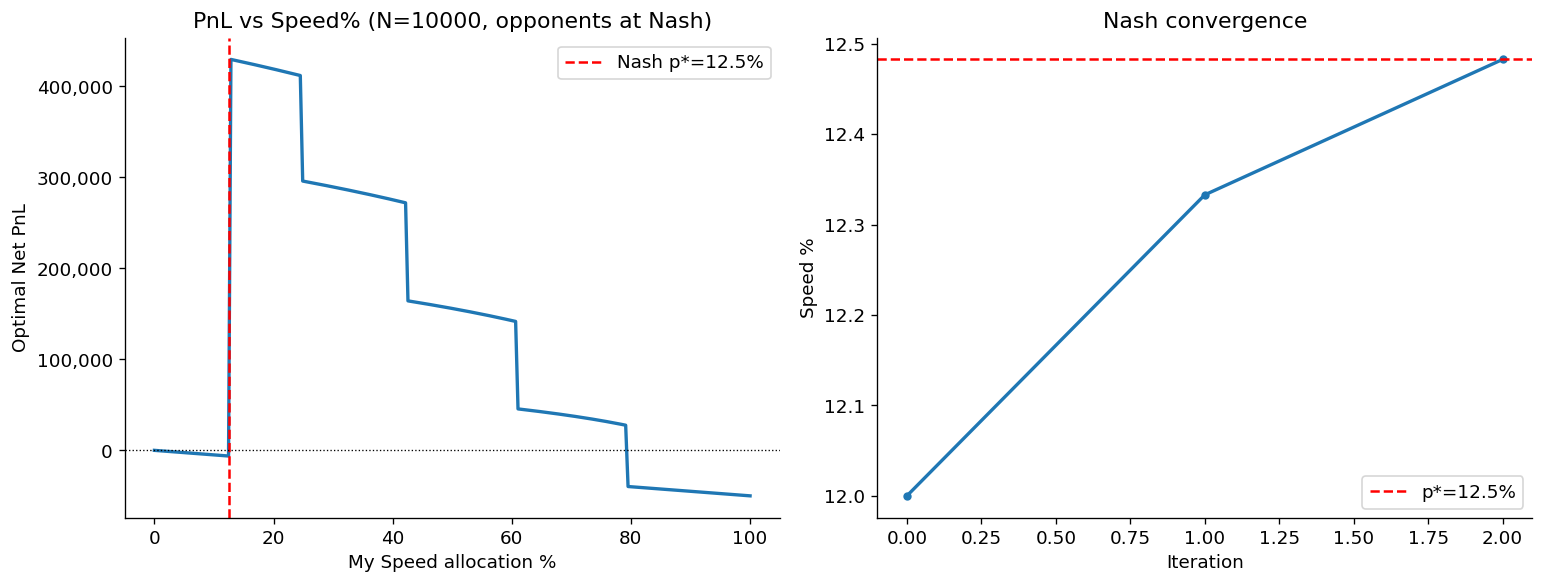

Nash Speed p* = 12.48% (6,241 XIRECs) for N=10000


In [36]:
# Detailed Nash convergence and best-response curve for N_PLAYERS
p_nash, hist_nash = symmetric_nash(N_PLAYERS)
opp_nash = [p_nash] * (N_PLAYERS - 1)
_, _, p_cands, pnl_cands = best_response_p(opp_nash, n_p=250)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(p_cands, pnl_cands, lw=2)
ax.axvline(p_nash, color='red', ls='--', lw=1.5, label=f'Nash p*={p_nash:.1f}%')
ax.axhline(0, color='k', ls=':', lw=0.8)
ax.set(xlabel='My Speed allocation %', ylabel='Optimal Net PnL',
       title=f'PnL vs Speed% (N={N_PLAYERS}, opponents at Nash)')
ax.yaxis.set_major_formatter(fmt)
ax.legend()

ax2 = axes[1]
ax2.plot(range(len(hist_nash)), hist_nash, lw=2, marker='o', ms=4)
ax2.axhline(p_nash, color='red', ls='--', lw=1.5, label=f'p*={p_nash:.1f}%')
ax2.set(xlabel='Iteration', ylabel='Speed %', title='Nash convergence')
ax2.legend()

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/nash_analysis.png', bbox_inches='tight')
plt.show()
print(f'Nash Speed p* = {p_nash:.2f}% ({p_nash/100*BUDGET:,.0f} XIRECs) for N={N_PLAYERS}')

## 7. Strategic Heatmap

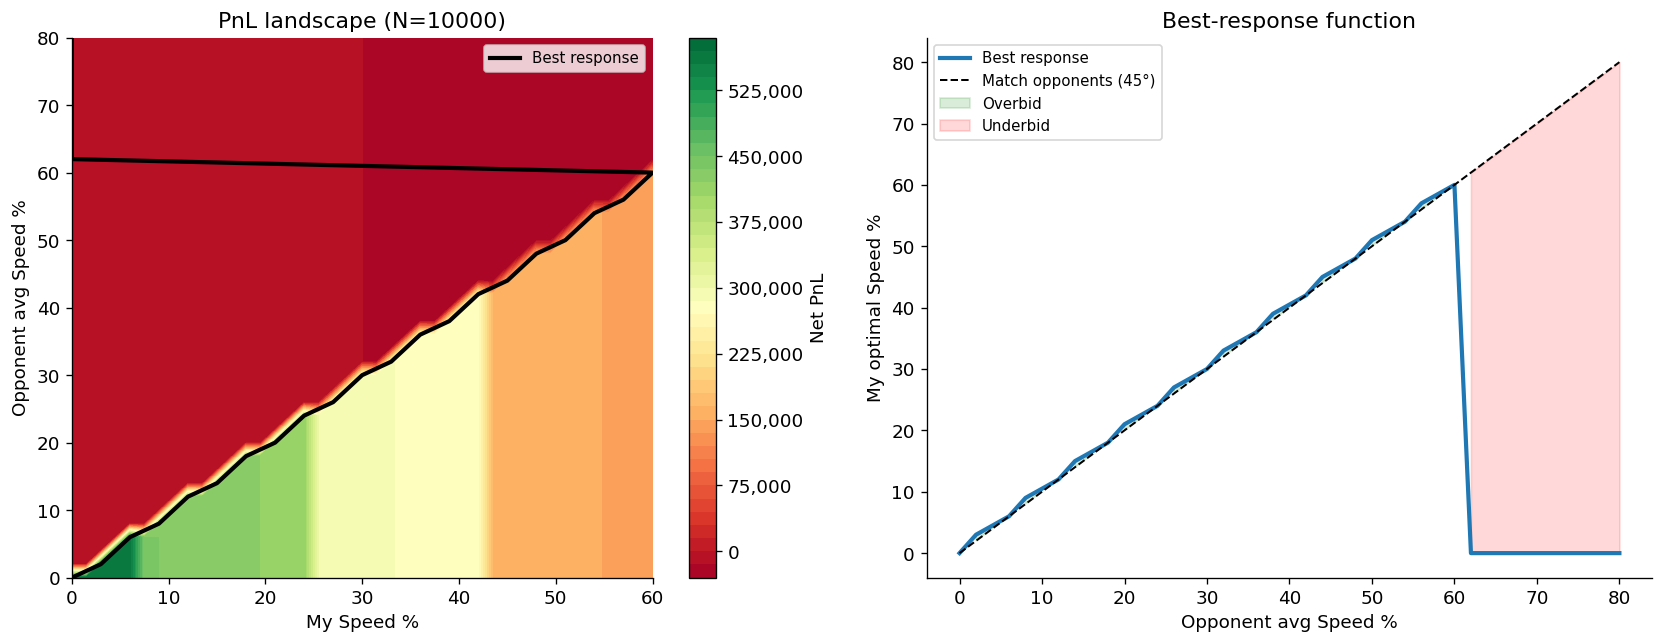

In [37]:
my_p_g  = np.linspace(0, 60, 41)
opp_p_g = np.linspace(0, 80, 41)
PNL_MAP = np.zeros((len(opp_p_g), len(my_p_g)))

for j, mp in enumerate(my_p_g):
    for i, op in enumerate(opp_p_g):
        opp_s = [op] * (N_PLAYERS - 1)
        my_m  = compute_speed_multipliers(opp_s + [mp])[-1]
        best_v = -np.inf
        for T in np.linspace(0, 100-mp, 80):
            r, s, _ = optimal_rs_given_total(T, my_m)
            v = pnl(r, s, mp, my_m)
            if v > best_v:
                best_v = v
        PNL_MAP[i, j] = best_v

best_my_p = my_p_g[np.argmax(PNL_MAP, axis=1)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
c = ax.contourf(my_p_g, opp_p_g, PNL_MAP, levels=50, cmap='RdYlGn')
plt.colorbar(c, ax=ax, label='Net PnL').ax.yaxis.set_major_formatter(fmt)
ax.plot(best_my_p, opp_p_g, 'k-', lw=2.5, label='Best response')
ax.set(xlabel='My Speed %', ylabel='Opponent avg Speed %',
       title=f'PnL landscape (N={N_PLAYERS})')
ax.legend(fontsize=9)

ax2 = axes[1]
ax2.plot(opp_p_g, best_my_p, lw=2.5, label='Best response')
ax2.plot(opp_p_g, opp_p_g, 'k--', lw=1.2, label='Match opponents (45°)')
ax2.fill_between(opp_p_g, best_my_p, opp_p_g,
                 where=best_my_p>opp_p_g, alpha=0.15, color='green', label='Overbid')
ax2.fill_between(opp_p_g, best_my_p, opp_p_g,
                 where=best_my_p<opp_p_g, alpha=0.15, color='red', label='Underbid')
ax2.set(xlabel='Opponent avg Speed %', ylabel='My optimal Speed %',
        title='Best-response function')
ax2.legend(fontsize=9)

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/competitive_strategy.png', bbox_inches='tight')
plt.show()

## 8. Rank-Jump Analysis: Exact Speed Thresholds

Opponent speed allocations (sorted): ['99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '99.0', '9

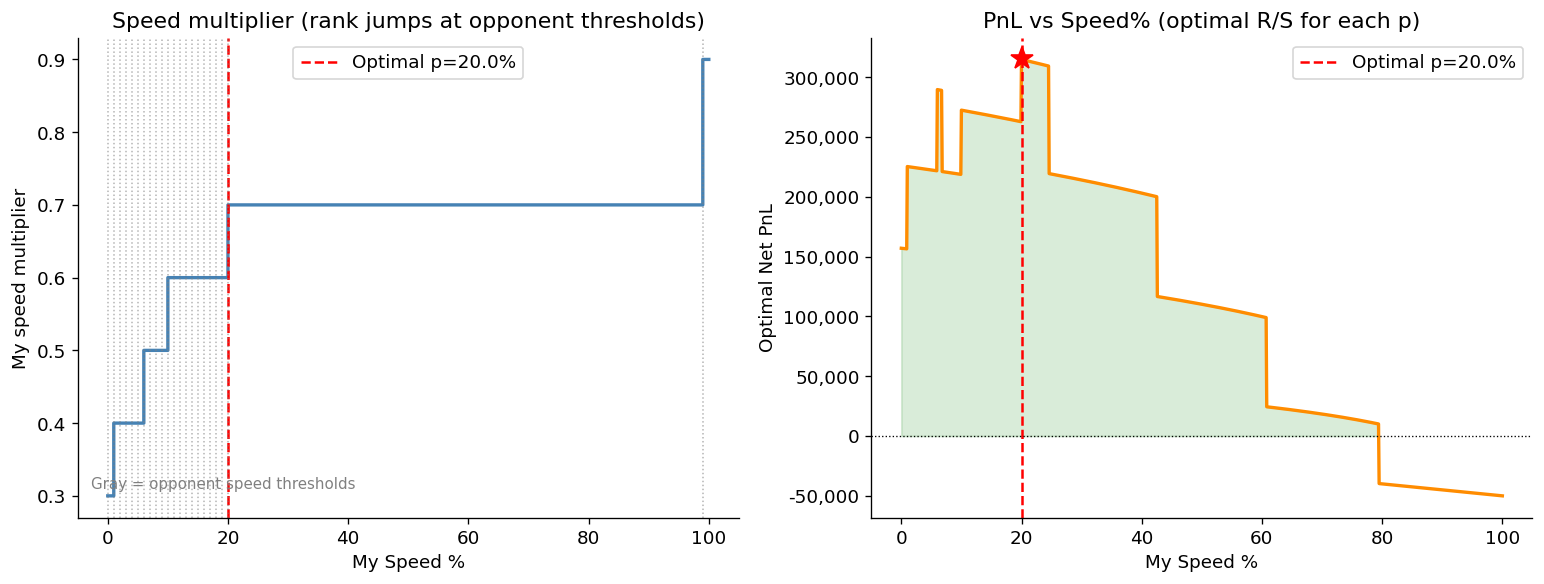


Optimal Speed allocation: 20.00% (10,000 XIRECs)
Speed multiplier:         0.7000
Net PnL:                  314,812.56


In [38]:
# ═══════════════════════════════════════════
# Set your belief about opponent speeds
# OPPONENT_SPEED_ALLOCS = [p_nash] * (N_PLAYERS - 1)
OPPONENT_SPEED_ALLOCS = (
    [0]  * int(N_PLAYERS * 0.30) +
    [1]  * int(N_PLAYERS * 0.10) +
    [2]  * int(N_PLAYERS * 0.02) +
    [3]  * int(N_PLAYERS * 0.02) +
    [4]  * int(N_PLAYERS * 0.01) +
    [5]  * int(N_PLAYERS * 0.05) +
    [6]  * int(N_PLAYERS * 0.02) +
    [7]  * int(N_PLAYERS * 0.02) +
    [8]  * int(N_PLAYERS * 0.01) +
    [9]  * int(N_PLAYERS * 0.01) +
    [10] * int(N_PLAYERS * 0.10) +
    [11] * int(N_PLAYERS * 0.01) +
    [12] * int(N_PLAYERS * 0.01) +
    [13] * int(N_PLAYERS * 0.01) +
    [14] * int(N_PLAYERS * 0.01) +
    [15] * int(N_PLAYERS * 0.01) +
    [16] * int(N_PLAYERS * 0.01) +
    [17] * int(N_PLAYERS * 0.01) +
    [18] * int(N_PLAYERS * 0.01) +
    [19] * int(N_PLAYERS * 0.01) +
    [20] * int(N_PLAYERS * 0.02) +
    [99] * int(N_PLAYERS * 0.24)
)
# ═══════════════════════════════════════════

opp = sorted(OPPONENT_SPEED_ALLOCS, reverse=True)
print(f'Opponent speed allocations (sorted): {[f"{x:.1f}" for x in opp]}')

p_fine = np.linspace(0, 100, 1001)
my_mults = np.array([compute_speed_multipliers(opp + [p])[-1] for p in p_fine])

pnl_curve = []
for p, m in zip(p_fine, my_mults):
    best_v = -np.inf
    for T in np.linspace(0, 100-p, 120):
        r, s, _ = optimal_rs_given_total(T, m)
        v = pnl(r, s, p, m)
        if v > best_v:
            best_v = v
    pnl_curve.append(best_v)

pnl_curve = np.array(pnl_curve)
best_p_idx = np.argmax(pnl_curve)
best_p_here = p_fine[best_p_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.step(p_fine, my_mults, lw=2, where='post', color='steelblue')
ax.axvline(best_p_here, color='red', ls='--', lw=1.5, label=f'Optimal p={best_p_here:.1f}%')
for ov in sorted(set(opp), reverse=True):
    ax.axvline(ov, color='gray', ls=':', lw=0.9, alpha=0.6)
ax.set(xlabel='My Speed %', ylabel='My speed multiplier',
       title='Speed multiplier (rank jumps at opponent thresholds)')
ax.legend()
ax.text(0.02, 0.06, 'Gray = opponent speed thresholds',
        transform=ax.transAxes, fontsize=9, color='gray')

ax2 = axes[1]
ax2.plot(p_fine, pnl_curve, lw=2, color='darkorange')
ax2.axvline(best_p_here, color='red', ls='--', lw=1.5, label=f'Optimal p={best_p_here:.1f}%')
ax2.axhline(0, color='k', ls=':', lw=0.8)
ax2.fill_between(p_fine, pnl_curve, 0, where=pnl_curve>0, alpha=0.15, color='green')
ax2.plot(best_p_here, pnl_curve[best_p_idx], 'r*', ms=14)
ax2.set(xlabel='My Speed %', ylabel='Optimal Net PnL',
        title='PnL vs Speed% (optimal R/S for each p)')
ax2.yaxis.set_major_formatter(fmt)
ax2.legend()

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/rank_jump.png', bbox_inches='tight')
plt.show()

m_at_best = compute_speed_multipliers(opp + [best_p_here])[-1]
print(f'\nOptimal Speed allocation: {best_p_here:.2f}% ({best_p_here/100*BUDGET:,.0f} XIRECs)')
print(f'Speed multiplier:         {m_at_best:.4f}')
print(f'Net PnL:                  {pnl_curve[best_p_idx]:,.2f}')

## 9. Final Recommendation Engine

In [39]:
# ═══════════════════════════════════════════════════════
# MASTER CONFIG — edit and re-run
# ═══════════════════════════════════════════════════════
TOTAL_PLAYERS = N_PLAYERS

# 'nash' | 'uniform_low' | 'uniform_mid' | 'uniform_high' | 'custom'
BELIEF_MODE = 'nash'
CUSTOM_OPP  = [10, 30, 50, 60, 70]  # Used only if BELIEF_MODE='custom'
# ═══════════════════════════════════════════════════════

mode_map = {
    'nash':         (lambda: ([p_nash]*(TOTAL_PLAYERS-1), f'Nash (p*={p_nash:.1f}%)')),
    'uniform_low':  (lambda: ([10]*(TOTAL_PLAYERS-1),     'All opponents 10%')),
    'uniform_mid':  (lambda: ([33]*(TOTAL_PLAYERS-1),     'All opponents 33%')),
    'uniform_high': (lambda: ([70]*(TOTAL_PLAYERS-1),     'All opponents 70%')),
    'custom':       (lambda: (CUSTOM_OPP[:TOTAL_PLAYERS-1], f'Custom: {CUSTOM_OPP}')),
}
opp_f, belief_str = mode_map[BELIEF_MODE]()

# Find optimal p
p_scan = np.linspace(0, 100, 601)
pnl_scan = np.array([pnl_for_p(p, opp_f, n_T=200) for p in p_scan])
p_opt_f = p_scan[np.argmax(pnl_scan)]

# Given best p, find best r, s
my_m_f = compute_speed_multipliers(opp_f + [p_opt_f])[-1]
r_f, s_f, _ = best_allocation(my_m_f, p_opt_f)
v_f = pnl(r_f, s_f, p_opt_f, my_m_f)

r_x = r_f/100*BUDGET
s_x = s_f/100*BUDGET
p_x = p_opt_f/100*BUDGET
spent = r_x + s_x + p_x
unspent = BUDGET - spent

W = 58
def row(a, b): print(f'║  {a:<28} {b:<{W-32}}║')
print('╔' + '═'*W + '╗')
print('║' + ' FINAL RECOMMENDATION '.center(W) + '║')
print('╠' + '═'*W + '╣')
row('Belief mode:', belief_str[:W-32])
row('Players:', str(TOTAL_PLAYERS))
print('╠' + '═'*W + '╣')
row('Research', f'{r_f:6.2f}%  →  {r_x:>10,.0f} XIRECs')
row('Scale',    f'{s_f:6.2f}%  →  {s_x:>10,.0f} XIRECs')
row('Speed',    f'{p_opt_f:6.2f}%  →  {p_x:>10,.0f} XIRECs')
row('Unspent',  f'        {unspent:>10,.0f} XIRECs')
print('╠' + '═'*W + '╣')
row('Research output:',  f'{research(r_f):>16,.2f}')
row('Scale output:',     f'{scale(s_f):>16.4f}')
row('Speed multiplier:', f'{my_m_f:>16.4f}')
row('Gross PnL:',        f'{research(r_f)*scale(s_f)*my_m_f:>16,.2f}')
row('Budget cost:',      f'{spent:>16,.2f}')
row('★ NET PnL:',        f'{v_f:>16,.2f}')
print('╚' + '═'*W + '╝')

# Comparison
print('\n── Scenario comparison ──')
scens = {'p=0 (no speed)':0, 'p=10%':10, '★ Optimal':p_opt_f,
         f'Nash ({p_nash:.1f}%)':p_nash, 'p=50%':50}
print(f"{'Scenario':<22} {'P%':>6} {'Speed×':>8} {'Net PnL':>14}")
print('-'*54)
for nm, pt in scens.items():
    mt = compute_speed_multipliers(opp_f + [pt])[-1]
    rt, st, vt = best_allocation(mt, pt)
    star = '  ← OPTIMAL' if '★' in nm else ''
    print(f"{nm:<22} {pt:>6.1f} {mt:>8.4f} {vt:>14,.1f}{star}")

╔══════════════════════════════════════════════════════════╗
║                   FINAL RECOMMENDATION                   ║
╠══════════════════════════════════════════════════════════╣
║  Belief mode:                 Nash (p*=12.5%)           ║
║  Players:                     10000                     ║
╠══════════════════════════════════════════════════════════╣
║  Research                      20.70%  →      10,352 XIRECs║
║  Scale                         66.80%  →      33,398 XIRECs║
║  Speed                         12.50%  →       6,250 XIRECs║
║  Unspent                                       0 XIRECs ║
╠══════════════════════════════════════════════════════════╣
║  Research output:                   133,366.61          ║
║  Scale output:                          4.0000          ║
║  Speed multiplier:                      0.9000          ║
║  Gross PnL:                         480,119.79          ║
║  Budget cost:                        50,000.00          ║
║  ★ NET PnL:             

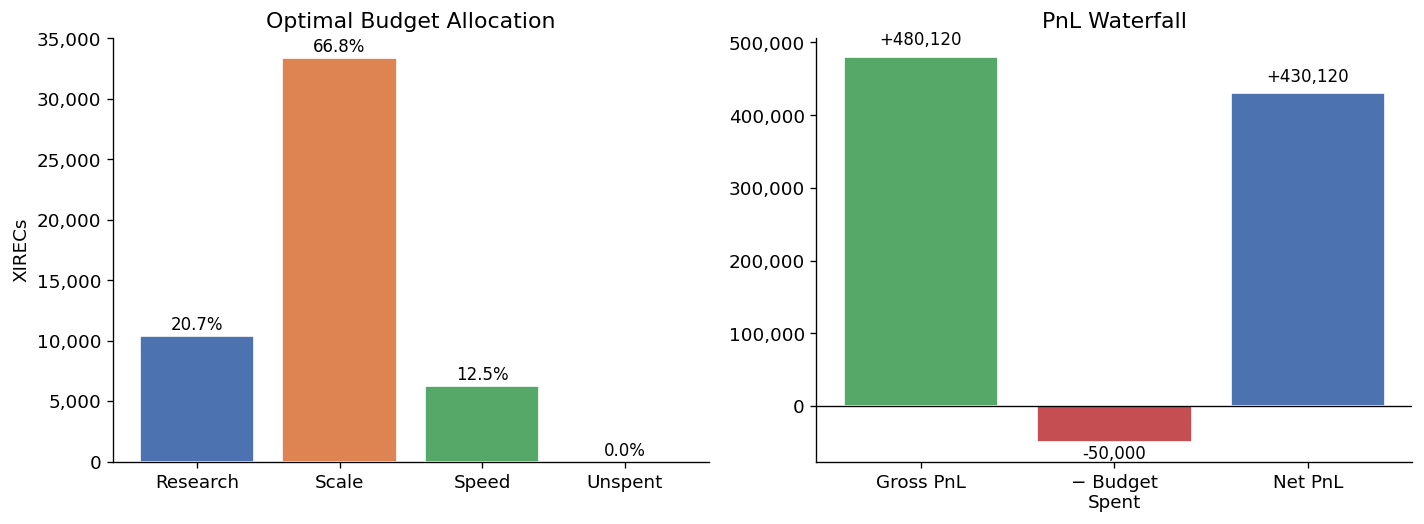

In [40]:
# Summary charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
labels = ['Research', 'Scale', 'Speed', 'Unspent']
vals   = [r_x, s_x, p_x, unspent]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C4C4C4']
bars = ax.bar(labels, vals, color=colors, edgecolor='white')
ax.set(ylabel='XIRECs', title='Optimal Budget Allocation')
ax.yaxis.set_major_formatter(fmt)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
            f'{v/BUDGET*100:.1f}%', ha='center', va='bottom', fontsize=10)

ax2 = axes[1]
gross = research(r_f)*scale(s_f)*my_m_f
wf_v = [gross, -spent, v_f]
wf_l = ['Gross PnL', '− Budget\nSpent', 'Net PnL']
wf_c = ['#55A868', '#C44E52', '#4C72B0']
ax2.bar(wf_l, wf_v, color=wf_c, edgecolor='white')
ax2.axhline(0, color='k', lw=0.8)
ax2.set(title='PnL Waterfall')
ax2.yaxis.set_major_formatter(fmt)
for i, (l, v) in enumerate(zip(wf_l, wf_v)):
    offset = max(abs(v)*0.025, 1000)
    ax2.text(i, v+(offset if v>=0 else -offset*2.5),
             f'{v:+,.0f}', ha='center',
             va='bottom' if v>=0 else 'top', fontsize=10)

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/final_recommendation.png', bbox_inches='tight')
plt.show()

## Key Takeaways

### 1. Analytical R/S split is robust
The first-order condition `s = (1+r)·ln(1+r)` pinpoints the optimal Research/Scale balance for any total allocation T. This holds regardless of speed multiplier — it is a mathematical invariant of the problem.

### 2. Speed is a zero-sum rank game
At the symmetric Nash equilibrium, all players end up with the **same** speed multiplier — the collective Speed investment is wasted. The key insight: invest in Speed **only** to jump past a specific opponent, then stop.

### 3. The rank-jump heuristic
Look at opponent speed allocations. Invest just above the highest opponent allocation you want to beat. Each additional XIREC beyond that threshold does nothing for your rank until you reach the next opponent's threshold.

### 4. When opponents over-invest in Speed
If competitors spend heavily on Speed, accept a low rank and maximize Research × Scale. The rank-multiplier range is 0.1–0.9, so even at rank-last you keep 11% of the gross you'd have at rank-first — while opponents sacrifice Research/Scale output.

### 5. Don't over-spend
The budget term is linear. If a pillar's marginal gross return (Research'(r) × Scale(s) × m) falls below 1% × 50,000 / 100 = 500 XIRECs per percentage point, stop spending. The optimal total allocation may well be below 100%.

### 6. Practical rule of thumb (no opponent info)
- ~60-65% Research, ~25-30% Scale, Nash-level Speed (~5-15% depending on field size).
- If you know opponents are speed-heavy: drop Speed to 0%, add to Research.
- If you know opponents are speed-light: just beat the highest allocation by 1% to claim rank 1.